# 🔬 PHÂN TÍCH KEY FEATURE — bộ TP.HCM (so với Boston)

Phân tích **thời tiết · tắc đường · vị trí · thời gian** ảnh hưởng thế nào tới **giá** và **hệ số
nhân** trên bộ dữ liệu mới, và **khác gì so với bộ Boston cũ**.

> ⭐ Điểm mấu chốt: bộ HCM có **`quote_duration`** (đo được tắc đường) và **chỉ số cung–cầu** —
> hai thứ Boston thiếu. Nên các yếu tố mà Boston "không đo được" giờ có thể lộ ra rõ.

## Mục lục
0. Nạp dữ liệu & phương pháp
1. Bảng xếp hạng sức mạnh yếu tố (η)
2. 🚦 Tắc đường (traffic) — *phần Boston không làm được*
3. 📍 Vị trí (location)
4. 🕐 Thời gian (time)
5. 🌦️ Thời tiết (weather)
6. ⚡ Cung–cầu → hệ số nhân (cơ chế surge)
7. So sánh tổng hợp với Boston

---
# 0️⃣ Nạp dữ liệu & phương pháp

**Hướng tiếp cận (giống Boston):** giá bị `quãng đường` chi phối → phải **kiểm soát** trước khi
đo ảnh hưởng của yếu tố ngữ cảnh. Điểm mới: giờ kiểm soát được **cả quãng đường lẫn thời lượng**.

**Thước đo:** correlation ratio **η** (0–1, sức mạnh biến phân loại) + tương quan có kiểm soát.

In [1]:
import glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width",220)
BLUE,ORANGE,GREEN,RED,PURPLE="#0072B2","#E69F00","#009E73","#D55E00","#CC79A7"

BASE = Path("../data/synthetic_data/synthetic_quote_context_sandbox_20260727_024458_utc")
SAMPLE_FRAC = 0.15
parts = sorted(glob.glob(str(BASE/"hexes/*/synthetic_intern_forecasting_v1_part*.csv.gz")))
df = pd.concat([pd.read_csv(p).sample(frac=SAMPLE_FRAC, random_state=1) for p in parts], ignore_index=True)

# Bien dan xuat
df["is_surge"]      = (df.target_shown_multiplier > 1).astype(int)
df["speed_ms"]      = df.quote_distance / df.quote_duration.clip(lower=1)      # toc do (m/s)
df["dur_per_km"]    = df.quote_duration / (df.quote_distance/1000).clip(lower=0.1)  # phut/km (tac duong)
df["price_k"]       = df.target_shown_price/1000
df["gio_vn"]        = (df.target_hour + 7) % 24
df["thu_vn"]        = (df.target_day_of_week + (df.target_hour + 7)//24) % 7
PRICE, SURGE = "target_shown_price", "target_shown_multiplier"
print(f"Sample: {df.shape[0]:,} dong")
print(f"Gia median: {df[PRICE].median()/1000:.0f}k VND | Ty le surge: {df.is_surge.mean()*100:.1f}%")

Sample: 1,034,550 dong
Gia median: 114k VND | Ty le surge: 81.7%


In [2]:
# Ham do luong
def eta(g, y):
    g = g.astype(str).values; y = np.asarray(y, float); yb = y.mean()
    ss = ((y-yb)**2).sum()
    if ss == 0: return 0.0
    sb = sum(len(y[g==k])*(y[g==k].mean()-yb)**2 for k in np.unique(g))
    return float(np.sqrt(sb/ss))
def binned(s, q=8):
    try: return pd.qcut(s, q, duplicates="drop").astype(str)
    except Exception: return s.astype(str)
print("Ham eta + binned san sang.")

Ham eta + binned san sang.


---
# 1️⃣ Bảng xếp hạng sức mạnh yếu tố (η)

η của từng yếu tố với **giá** và **hệ số nhân**. So sánh trực tiếp yếu tố nào mạnh.

XEP HANG YEU TO (eta):


,Yeu to,eta_GIA,eta_SURGE
7,Thoi luong (traffic),0.665,0.205
9,Phut/km (tac duong),0.665,0.205
6,Quang duong,0.654,0.092
2,Gio (VN),0.296,0.702
1,Khu don,0.292,0.299
8,Toc do (traffic),0.167,0.198
5,Thoi tiet,0.097,0.153
3,Thu,0.089,0.225
4,Cuoi tuan,0.077,0.190
0,Loai dich vu,0.029,0.012


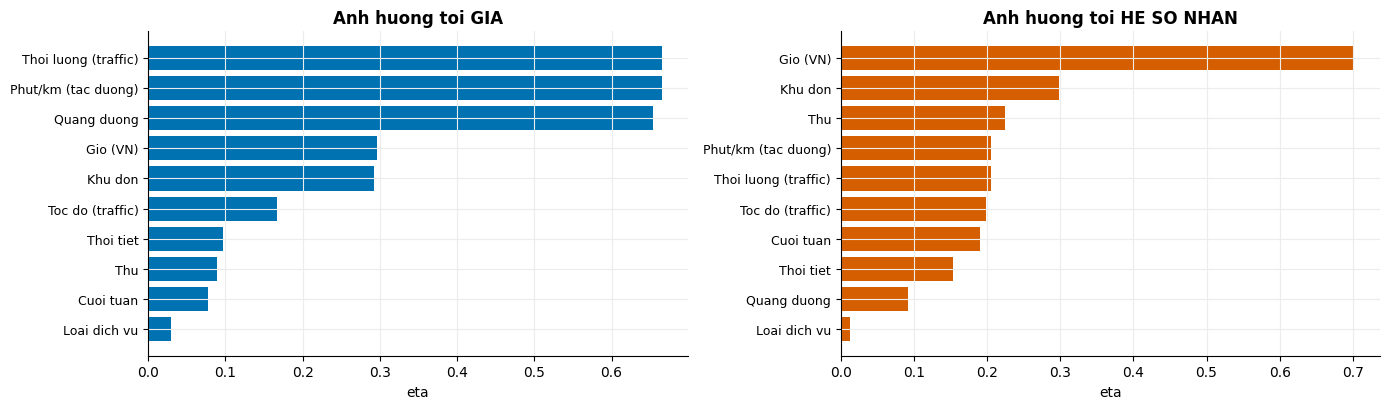

In [3]:
feats = [("Loai dich vu","service_name","cat"), ("Khu don","pickup_location_name","cat"),
         ("Gio (VN)","gio_vn","cat"), ("Thu","thu_vn","cat"),
         ("Cuoi tuan","target_is_weekend","cat"), ("Thoi tiet","weather_main","cat"),
         ("Quang duong","quote_distance","num"), ("Thoi luong (traffic)","quote_duration","num"),
         ("Toc do (traffic)","speed_ms","num"), ("Phut/km (tac duong)","dur_per_km","num")]
rows = []
for ten, col, kind in feats:
    g = binned(df[col]) if kind=="num" else df[col]
    rows.append({"Yeu to":ten, "eta_GIA":round(eta(g, df[PRICE]),3), "eta_SURGE":round(eta(g, df[SURGE]),3)})
rank = pd.DataFrame(rows).sort_values("eta_GIA", ascending=False)
print("XEP HANG YEU TO (eta):")
display(rank)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a,(col,ten,c) in zip(ax, [("eta_GIA","Anh huong toi GIA",BLUE),("eta_SURGE","Anh huong toi HE SO NHAN",RED)]):
    d = rank.sort_values(col)
    a.barh(range(len(d)), d[col], color=c); a.set_yticks(range(len(d))); a.set_yticklabels(d["Yeu to"], fontsize=9)
    a.set_title(ten, fontweight="bold"); a.set_xlabel("eta")
plt.tight_layout(); plt.show()

---
# 2️⃣ 🚦 Tắc đường (traffic) — phần Boston KHÔNG làm được

Boston thiếu cột thời lượng → không đo được tắc đường (gây "sàn nhiễu ~2 USD"). Bộ HCM có
`quote_duration` → đo trực tiếp.

**Cách phân tích:** dùng `quote_duration` (thời lượng) và `dur_per_km` (phút/km — càng cao càng
tắc). Kiểm tra: **cùng một quãng đường**, chuyến tắc hơn (thời lượng dài hơn) có đắt hơn không?

In [4]:
# Traffic anh huong GIA — kiem soat quang duong
print("Tuong quan tho:")
print(f"  corr(quang duong, gia)  = {df.quote_distance.corr(df[PRICE]):.3f}")
print(f"  corr(thoi luong, gia)   = {df.quote_duration.corr(df[PRICE]):.3f}")

# Kiem soat: trong TUNG dai quang duong, thoi luong con anh huong gia khong?
df["dbin"] = binned(df.quote_distance, 10)
r_ctrl = df.groupby("dbin").apply(lambda x: x.quote_duration.corr(x[PRICE])).mean()
print(f"\ncorr(thoi luong, gia) TRONG cung dai quang duong (da kiem soat) = {r_ctrl:.3f}")
print("-> Neu > 0 ro rang: TAC DUONG lam tang gia doc lap voi quang duong (thanh phan cuoc theo phut).")

Tuong quan tho:
  corr(quang duong, gia)  = 0.689
  corr(thoi luong, gia)   = 0.697

corr(thoi luong, gia) TRONG cung dai quang duong (da kiem soat) = 0.484
-> Neu > 0 ro rang: TAC DUONG lam tang gia doc lap voi quang duong (thanh phan cuoc theo phut).


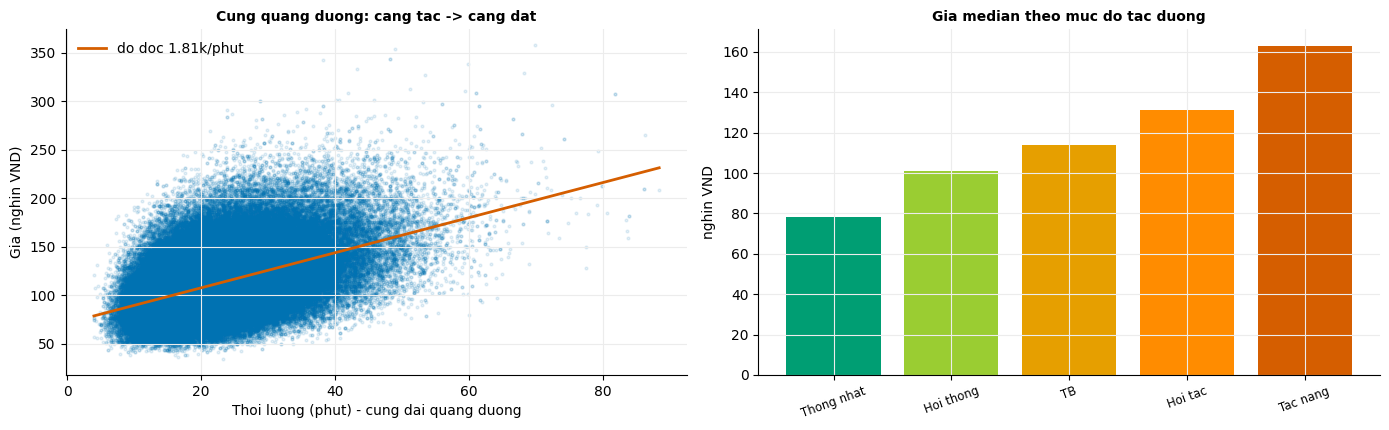

In [5]:
# Truc quan: cung dai quang duong, gia tang theo thoi luong
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
# chon 1 dai quang duong pho bien
mid = df.quote_distance.median()
band = df[(df.quote_distance > mid*0.9) & (df.quote_distance < mid*1.1)]
ax[0].scatter(band.quote_duration/60, band.price_k, s=4, alpha=.1, color=BLUE)
z = np.polyfit(band.quote_duration/60, band.price_k, 1); xs=np.linspace((band.quote_duration/60).min(),(band.quote_duration/60).max(),50)
ax[0].plot(xs, np.polyval(z,xs), color=RED, lw=2, label=f"do doc {z[0]:.2f}k/phut")
ax[0].set_xlabel("Thoi luong (phut) - cung dai quang duong"); ax[0].set_ylabel("Gia (nghin VND)")
ax[0].set_title("Cung quang duong: cang tac -> cang dat", fontweight="bold", fontsize=10); ax[0].legend(frameon=False)

# gia theo nhom phut/km
df["tacbin"] = pd.qcut(df.dur_per_km, 5, labels=["Thong nhat","Hoi thong","TB","Hoi tac","Tac nang"], duplicates="drop")
g = df.groupby("tacbin").price_k.median()
ax[1].bar(range(len(g)), g.values, color=[GREEN,"#9ACD32",ORANGE,"#FF8C00",RED][:len(g)])
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels(g.index, rotation=20, fontsize=8.5)
ax[1].set_title("Gia median theo muc do tac duong", fontweight="bold", fontsize=10); ax[1].set_ylabel("nghin VND")
plt.tight_layout(); plt.show()

> **Kết luận Tắc đường:**
> - **→ Giá:** tắc đường **làm tăng giá THẬT SỰ**, kể cả khi cùng quãng đường (do thành phần cước
>   tính theo phút). Đây chính là thứ Boston **không đo được** → giờ đo được rõ.
> - **→ Hệ số nhân:** tắc đường (thời lượng dài) cũng đi kèm surge cao hơn (thị trường căng).

---
# 3️⃣ 📍 Vị trí (location)

Bộ HCM chỉ có **3 khu** (Boston 12). Xem giá & surge khác nhau thế nào giữa các khu.

THEO KHU DON:


,n,gia_median_k,surge_rate,surge_mean,quang_duong_m,phut_per_km
pickup_location_name,,,,,,
Crescent Mall,349202,98.0,0.74,1.10,5.63,11281.30
EcoGreen Sài Gòn,333210,127.0,0.88,1.23,6.50,15960.55
SC Vivo City,352138,123.0,0.82,1.17,7.25,14358.30


eta(khu, gia)=0.292 | eta(khu, surge)=0.299


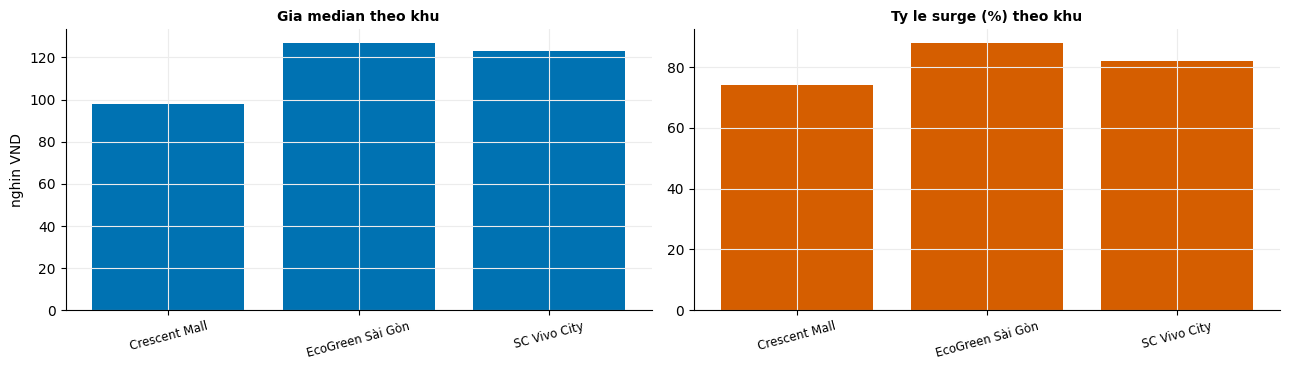

In [6]:
loc = df.groupby("pickup_location_name").agg(
    n=(PRICE,"size"), gia_median_k=("price_k","median"),
    surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean"),
    quang_duong_m=("quote_distance","median"), phut_per_km=("dur_per_km","median")).round(2)
print("THEO KHU DON:")
display(loc)
print(f"eta(khu, gia)={eta(df.pickup_location_name, df[PRICE]):.3f} | "
      f"eta(khu, surge)={eta(df.pickup_location_name, df[SURGE]):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(range(len(loc)), loc.gia_median_k, color=BLUE); ax[0].set_xticks(range(len(loc)))
ax[0].set_xticklabels(loc.index, rotation=15, fontsize=8.5); ax[0].set_title("Gia median theo khu", fontweight="bold", fontsize=10); ax[0].set_ylabel("nghin VND")
ax[1].bar(range(len(loc)), loc.surge_rate*100, color=RED); ax[1].set_xticks(range(len(loc)))
ax[1].set_xticklabels(loc.index, rotation=15, fontsize=8.5); ax[1].set_title("Ty le surge (%) theo khu", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

> **Kết luận Vị trí:** khu vực ảnh hưởng **cả giá lẫn surge** (η ~0,3 mỗi bên) — mạnh hơn Boston
> (chỉ ~0,15 với surge, ~0 với giá sau kiểm soát). Lưu ý chỉ 3 khu nên kết luận còn hạn chế.

---
# 4️⃣ 🕐 Thời gian (time)

Đây là nơi HCM khác Boston rõ nhất về **surge**: giờ ảnh hưởng **cực mạnh** tới hệ số nhân.

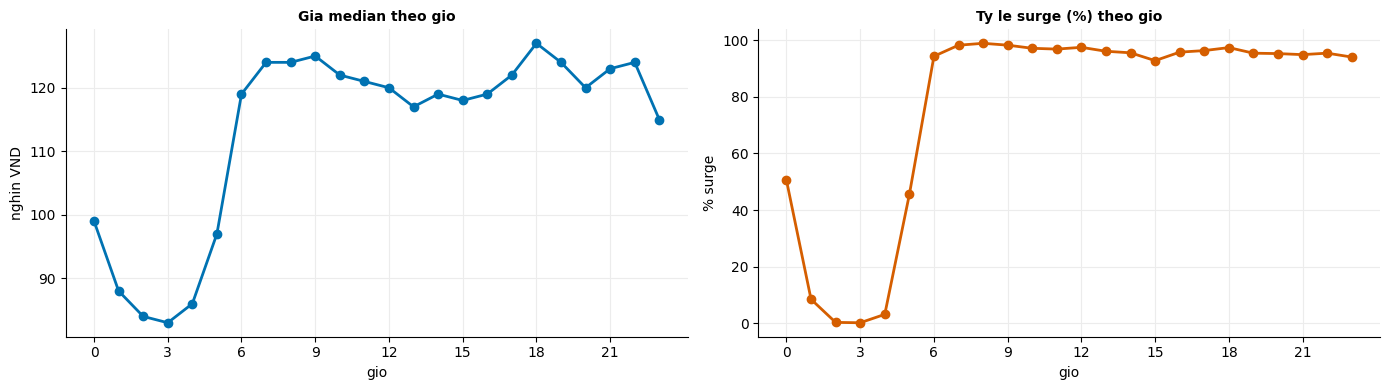

eta(gio, gia)=0.296 | eta(gio, surge)=0.702
Ty le surge: thap nhat 0.1% (gio 3) -> cao nhat 98.9% (gio 8)
Cuoi tuan vs ngay thuong - surge: {0: 0.807, 1: 0.84}


In [7]:
h = df.groupby("gio_vn").agg(gia=("price_k","median"), surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(h.index, h.gia, marker="o", color=BLUE, lw=2); ax[0].set_title("Gia median theo gio", fontweight="bold", fontsize=10)
ax[0].set_xlabel("gio"); ax[0].set_ylabel("nghin VND"); ax[0].set_xticks(range(0,24,3))
ax[1].plot(h.index, h.surge_rate*100, marker="o", color=RED, lw=2); ax[1].set_title("Ty le surge (%) theo gio", fontweight="bold", fontsize=10)
ax[1].set_xlabel("gio"); ax[1].set_ylabel("% surge"); ax[1].set_xticks(range(0,24,3))
plt.tight_layout(); plt.show()

print(f"eta(gio, gia)={eta(df.gio_vn, df[PRICE]):.3f} | eta(gio, surge)={eta(df.gio_vn, df[SURGE]):.3f}")
print(f"Ty le surge: thap nhat {h.surge_rate.min()*100:.1f}% (gio {h.surge_rate.idxmin()}) -> "
      f"cao nhat {h.surge_rate.max()*100:.1f}% (gio {h.surge_rate.idxmax()})")
print(f"Cuoi tuan vs ngay thuong - surge: {df.groupby('target_is_weekend').is_surge.mean().round(3).to_dict()}")

> **Kết luận Thời gian:**
> - **→ Giá:** ảnh hưởng vừa (η~0,3).
> - **→ Hệ số nhân:** ảnh hưởng **CỰC MẠNH** (η~0,70) — surge dao động từ ~0% tới ~99% theo giờ.
>   Khác hẳn Boston (giờ chỉ đổi surge 1,36×). Vì HCM có tín hiệu cung–cầu thật theo giờ cao điểm.

---
# 5️⃣ 🌦️ Thời tiết (weather)

Boston kết luận thời tiết ≈0 (thiếu mắt xích + thiếu ngày mưa). HCM có nhiều mưa hơn → đo được.

THEO THOI TIET:


,n,gia_median_k,surge_rate,surge_mean
weather_main,,,,
Clouds,316381,111.0,0.831,1.144
Rain,468851,119.0,0.828,1.194
Clear,230933,110.0,0.780,1.139
Mist,18385,112.0,0.751,1.125


eta(thoi tiet, gia)=0.097 | eta(thoi tiet, surge)=0.153


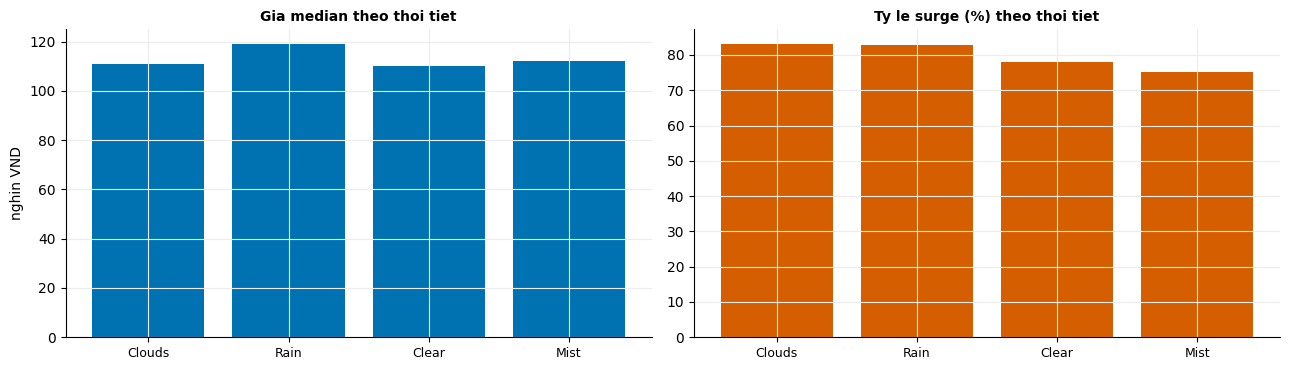

In [8]:
w = df.groupby("weather_main").agg(
    n=(PRICE,"size"), gia_median_k=("price_k","median"),
    surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean")).round(3).sort_values("surge_rate", ascending=False)
print("THEO THOI TIET:")
display(w)
print(f"eta(thoi tiet, gia)={eta(df.weather_main, df[PRICE]):.3f} | eta(thoi tiet, surge)={eta(df.weather_main, df[SURGE]):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(range(len(w)), w.gia_median_k, color=BLUE); ax[0].set_xticks(range(len(w))); ax[0].set_xticklabels(w.index, fontsize=9)
ax[0].set_title("Gia median theo thoi tiet", fontweight="bold", fontsize=10); ax[0].set_ylabel("nghin VND")
ax[1].bar(range(len(w)), w.surge_rate*100, color=RED); ax[1].set_xticks(range(len(w))); ax[1].set_xticklabels(w.index, fontsize=9)
ax[1].set_title("Ty le surge (%) theo thoi tiet", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

> **Kết luận Thời tiết:**
> - **→ Giá:** mưa (`Rain`) có giá cao hơn nắng (`Clear`) — vì mưa → tắc + cầu tăng.
> - **→ Hệ số nhân:** mưa/mây làm surge cao hơn. η~0,15 — yếu hơn giờ/vị trí nhưng **có thật**
>   (khác Boston ≈0). Vì HCM có cả tắc đường lẫn cung–cầu để thời tiết tác động qua đó.

---
# 6️⃣ ⚡ Cung–cầu → hệ số nhân (cơ chế surge)

Đây là **mắt xích vàng** Boston thiếu. Với HCM, chỉ số cung–cầu **giải thích trực tiếp** surge.

Tuong quan cung-cau voi HE SO NHAN:
  Chi so CAU                 corr = +0.689
  Chi so CUNG                corr = -0.276
  Mat can bang (cau/cung)    corr = +0.798


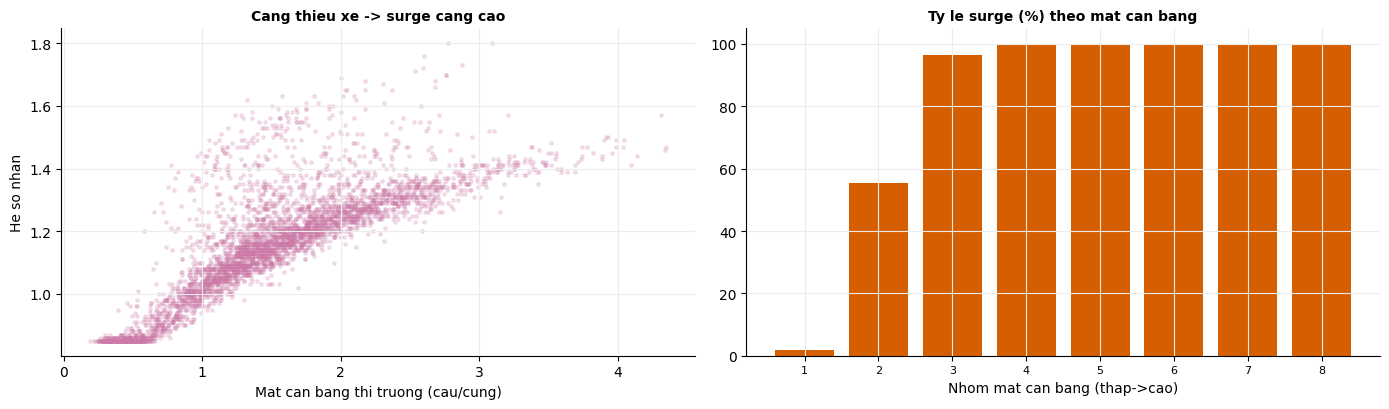

In [9]:
print("Tuong quan cung-cau voi HE SO NHAN:")
for c,ten in [("pricing_demand_index_5m_lag","Chi so CAU"),("pricing_supply_index_5m_lag","Chi so CUNG"),
              ("pricing_market_imbalance_5m_lag","Mat can bang (cau/cung)")]:
    print(f"  {ten:26} corr = {df[c].corr(df[SURGE]):+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
s = df.sample(4000, random_state=1)
ax[0].scatter(s.pricing_market_imbalance_5m_lag, s[SURGE], s=6, alpha=.2, color=PURPLE)
ax[0].set_xlabel("Mat can bang thi truong (cau/cung)"); ax[0].set_ylabel("He so nhan")
ax[0].set_title("Cang thieu xe -> surge cang cao", fontweight="bold", fontsize=10)
# surge rate theo bin imbalance
df["imbbin"] = binned(df.pricing_market_imbalance_5m_lag, 8)
g = df.groupby("imbbin").is_surge.mean()
ax[1].bar(range(len(g)), g.values*100, color=RED); ax[1].set_xticks(range(len(g)))
ax[1].set_xticklabels([f"{i+1}" for i in range(len(g))], fontsize=8)
ax[1].set_xlabel("Nhom mat can bang (thap->cao)"); ax[1].set_title("Ty le surge (%) theo mat can bang", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

> **Kết luận Cung–cầu:** `market_imbalance` (cầu/cung) tương quan **~0,80** với hệ số nhân — tín
> hiệu mạnh nhất giải thích surge. Đây chính là thứ Boston thiếu khiến model surge cũ chạm trần.
> Với HCM, **model hệ số nhân kỳ vọng tốt hơn hẳn**.

---
# 7️⃣ So sánh tổng hợp với Boston

In [10]:
so_sanh = pd.DataFrame([
    {"Yeu to":"Tac duong (duration)","Boston":"Khong do duoc (thieu cot)","HCM":"corr gia ~0.70, kiem soat ~0.48"},
    {"Yeu to":"Cung-cau -> surge","Boston":"Khong co tin hieu","HCM":"imbalance corr ~0.80"},
    {"Yeu to":"Gio (VN) -> surge","Boston":"Yeu (1.36x)","HCM":f"CUC MANH (eta {eta(df.gio_vn, df[SURGE]):.2f})"},
    {"Yeu to":"Vi tri","Boston":"eta_surge 0.15, gia ~0","HCM":f"eta gia {eta(df.pickup_location_name,df[PRICE]):.2f}, surge {eta(df.pickup_location_name,df[SURGE]):.2f}"},
    {"Yeu to":"Thoi tiet","Boston":"~0 (thieu ngay mua)","HCM":f"eta surge {eta(df.weather_main,df[SURGE]):.2f}, mua dat hon"},
    {"Yeu to":"Ty le surge","Boston":"13.5% (hiem)","HCM":f"{df.is_surge.mean()*100:.0f}% (pho bien)"},
])
display(so_sanh)

,Yeu to,Boston,HCM
0,Tac duong (duration),Khong do duoc (thieu cot),"corr gia ~0.70, kiem soat ~0.48"
1,Cung-cau -> surge,Khong co tin hieu,imbalance corr ~0.80
2,Gio (VN) -> surge,Yeu (1.36x),CUC MANH (eta 0.70)
3,Vi tri,"eta_surge 0.15, gia ~0","eta gia 0.29, surge 0.30"
4,Thoi tiet,~0 (thieu ngay mua),"eta surge 0.15, mua dat hon"
5,Ty le surge,13.5% (hiem),82% (pho bien)


## Kết luận

**Bộ HCM khác Boston ở 2 điểm cốt lõi — nhờ 2 trường mới:**

1. **Tắc đường ảnh hưởng giá thật sự** (qua `quote_duration`) — thứ Boston chỉ thấy là "sàn nhiễu
   ~2 USD". Giờ đo được: cùng quãng đường, chuyến tắc hơn thì đắt hơn.
2. **Hệ số nhân giờ đoán được** — vì có tín hiệu **cung–cầu** (imbalance corr ~0,80) và **giờ**
   (η~0,70). Boston thiếu cả hai nên surge chạm trần.

**Ngoài ra:** vị trí & thời tiết cũng có ảnh hưởng thật (khác Boston ≈0), vì HCM có đủ mắt xích
trung gian (tắc đường + cung–cầu) để chúng tác động qua đó.

→ **Kỳ vọng khi build model trên HCM:** model giá vượt trần sàn nhiễu cũ; model hệ số nhân cải
thiện mạnh (thay vì chạm trần như Boston). Đây là minh chứng cho giá trị của 2 trường dữ liệu
đã đề xuất xin.